## В данном ноутбуке проведем сегментный анализ результатов A/B теста.

Сегментный анализ выполним по:

- типу устройства пользователя;
- локации пользователя.

Наша цель - это определить, сохраняется ли эффект в различных подгруппах пользователей и имеются ли сегменты, в которых тестовый вариант работает лучше или хуже.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Загружаем данные

In [2]:
df = pd.read_csv('../processed_files/ab_testing_processed.csv')
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location,Conversion_binary
0,14292,B,3,424,No,Mobile,Northern Ireland,0
1,11682,A,9,342,No,Mobile,Scotland,0
2,19825,A,2,396,No,Desktop,Northern Ireland,0
3,16080,B,4,318,No,Desktop,Wales,0
4,18851,A,1,338,Yes,Desktop,Scotland,1


Проведем анализ коэффициента конверсии по типу устройства

In [3]:
device_conversion = (
    df.groupby(['Device', 'Group'])['Conversion_binary']
    .mean().reset_index())
device_conversion['Conversion_percent'] = device_conversion['Conversion_binary'] * 100
device_conversion

,Device,Group,Conversion_binary,Conversion_percent
0,Desktop,A,0.058682,5.868167
1,Desktop,B,0.139104,13.910355
2,Mobile,A,0.049412,4.941176
3,Mobile,B,0.142376,14.237574


Построим график конверсии по устройствам

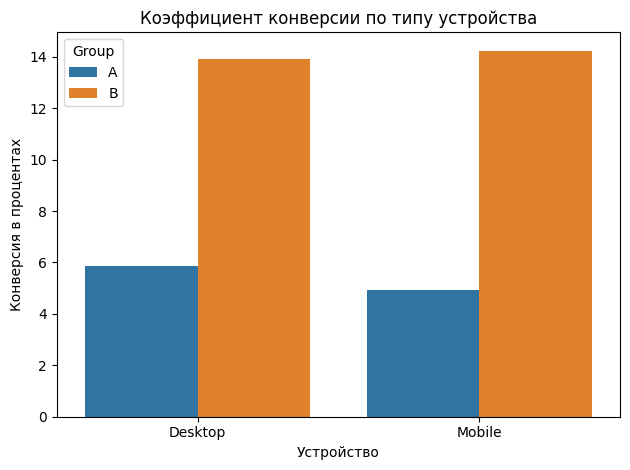

In [4]:
sns.barplot(data = device_conversion, x = 'Device', y = 'Conversion_percent', hue = 'Group')
plt.title('Коэффициент конверсии по типу устройства')
plt.xlabel('Устройство')
plt.ylabel('Конверсия в процентах')
plt.tight_layout()
plt.show()

Тестовая группа B демонстрирует более высокий коэффициент конверсии как для desktop, так и для mobile.

Построим сводную таблицу позитивной конверсии по устройствам

In [5]:
device_heatmap = df.pivot_table(
    index = 'Device',
    columns = 'Group',
    values = 'Conversion_binary',
    aggfunc = 'mean'
)*100
device_heatmap

Group,A,B
Device,,
Desktop,5.868167,13.910355
Mobile,4.941176,14.237574


Построим тепловую карту позитивной конверсии по устройствам

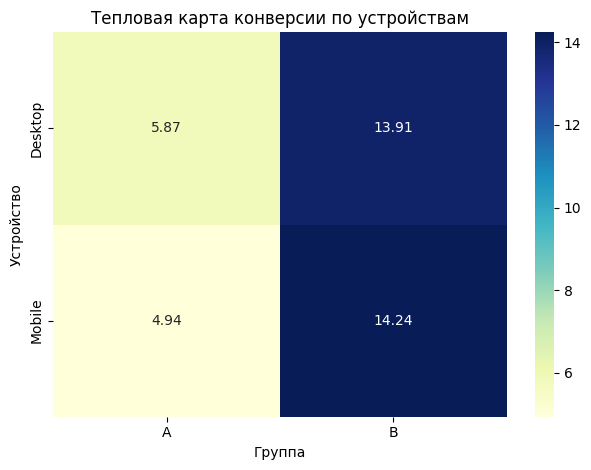

In [ ]:
sns.heatmap(device_heatmap, annot = True, fmt = '.2f', cmap = 'YlGnBu')
plt.title('Тепловая карта конверсии по устройствам')
plt.xlabel('Группа')
plt.ylabel('Устройство')
plt.tight_layout()
plt.show()

Тепловая карта показывает, что группа B демонстрирует более высокий коэффициент конверсии как для пользователей с компьютера, так и для пользователей с телефона.
При этом прирост конверсии с мобильного устрйства выражен сильнее, чем в компьютерном сегменте.
Это указывает на устойчивость эффекта тестового варианта в различных типах устройств.

Проведем анализ коэффициента конверсии в зависимости от локации пользователя

In [7]:
location_conversion = (
    df.groupby(['Location', 'Group'])['Conversion_binary']
    .mean()
    .reset_index()
)
location_conversion['Conversion_percent'] = location_conversion['Conversion_binary'] * 100
location_conversion

,Location,Group,Conversion_binary,Conversion_percent
0,England,A,0.069307,6.930693
1,England,B,0.146875,14.687500
2,Northern Ireland,A,0.050489,5.048860
3,Northern Ireland,B,0.114650,11.464968
4,Scotland,A,0.049254,4.925373
5,Scotland,B,0.150573,15.057283
6,Wales,A,0.047695,4.769475
7,Wales,B,0.151163,15.116279


Построим столбчатую диаграмму коэффициента конверсии по локациям

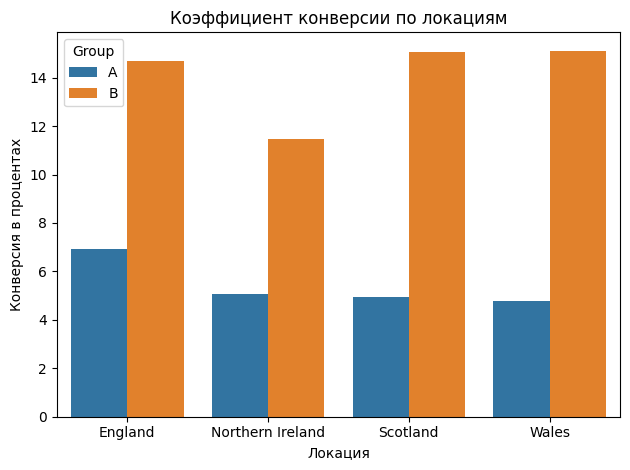

In [8]:
sns.barplot(data = location_conversion, x = 'Location', y = 'Conversion_percent', hue = 'Group')
plt.title('Коэффициент конверсии по локациям')
plt.xlabel('Локация')
plt.ylabel('Конверсия в процентах')
plt.tight_layout()
plt.show()

Во всех локациях тестовая группа B демонстрирует более высокий коэффициент конверсии по сравнению с группой A.
Наиболее выраженное различие наблюдается в Scotland и Wales, где уровень конверсии в группе B превышает 15%, тогда как в группе A остаётся около 5%.
В England также фиксируется заметный прирост конверсии, тогда как в Northern Ireland различие между группами выражено слабее по сравнению с другими сегментами.

Построим сводную таблицу и тепловую карту позитивной конверсии по локациям

In [ ]:
location_heatmap = df.pivot_table(
    index = 'Location',
    columns = 'Group',
    values = 'Conversion_binary',
    aggfunc = 'mean'
) * 100
location_heatmap

Group,A,B
Location,,
England,6.930693,14.687500
Northern Ireland,5.048860,11.464968
Scotland,4.925373,15.057283
Wales,4.769475,15.116279


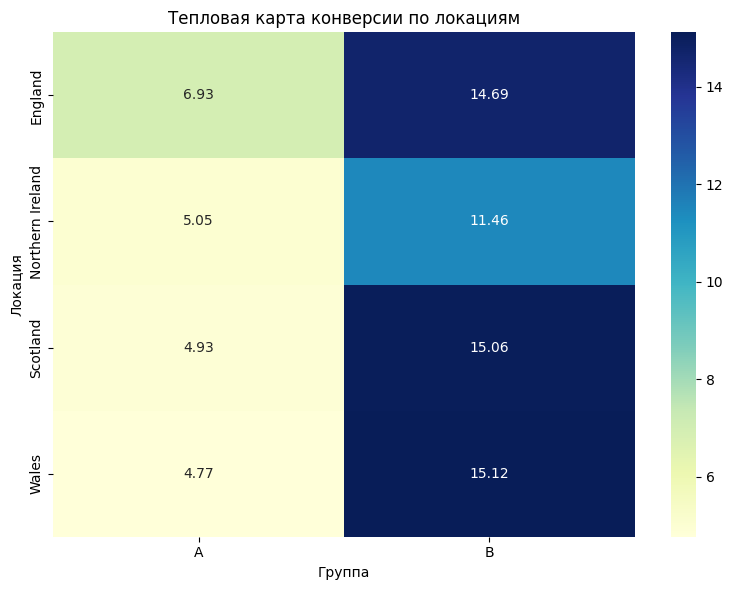

In [11]:
plt.figure(figsize = (8, 6))
sns.heatmap(location_heatmap, annot = True, fmt = '.2f', cmap = 'YlGnBu')
plt.title('Тепловая карта конверсии по локациям')
plt.xlabel('Группа')
plt.ylabel('Локация')
plt.tight_layout()
plt.show()

Во всех сегментах тестовая группа B демонстрирует более высокий коэффициент конверсии по сравнению с контрольной группой A.
Наиболее высокие значения конверсии в группе B наблюдаются в Wales и Scotland, где показатель превышает 15%.
Минимальный коэффициент конверсии в группе B фиксируется в Northern Ireland, однако даже в этом сегменте тестовая группа сохраняет заметное преимущество над контрольной.

Сравним прирост конверсии по сегментам

In [13]:
device_uplift = device_heatmap.copy()
device_uplift['B - A'] = device_uplift['B'] - device_uplift['A']
device_uplift

Group,A,B,B - A
Device,,,
Desktop,5.868167,13.910355,8.042188
Mobile,4.941176,14.237574,9.296397


In [15]:
location_uplift = location_heatmap.copy()
location_uplift['B - A'] = location_heatmap['B'] - location_heatmap['A']
location_uplift

Group,A,B,B - A
Location,,,
England,6.930693,14.687500,7.756807
Northern Ireland,5.048860,11.464968,6.416108
Scotland,4.925373,15.057283,10.131910
Wales,4.769475,15.116279,10.346804


Визуализируем разницу конверсий по устройствам (столбчатая диаграмма)

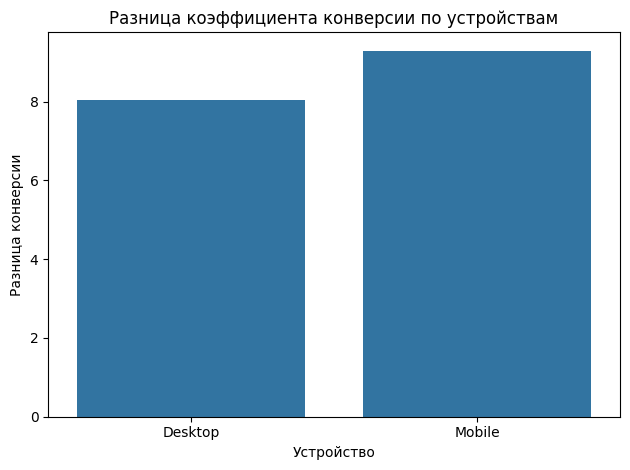

In [16]:
sns.barplot(
    x = device_uplift.index,
    y = device_uplift['B - A']
)
plt.title('Разница коэффициента конверсии по устройствам')
plt.xlabel('Устройство')
plt.ylabel('Разница конверсии')
plt.tight_layout()
plt.show()

Для каждого типа устройства рассчитали абсолютную разницу коэффициента конверсии между тестовой и контрольной группами.
Результаты показывают, что в обоих сегментах тестовая группа B демонстрирует более высокий коэффициент конверсии по сравнению с группой A.
На устройствах desktop прирост конверсии составляет около 8 процентов, тогда как на mobile различие достигает более 9 процентов.
Это указывает на то, что эффект изменения сохраняется независимо от типа устройства, однако на mobile он выражен немного сильнее.

Визуализируем разницу в конверсии по локациям (столбчатая диаграмма)

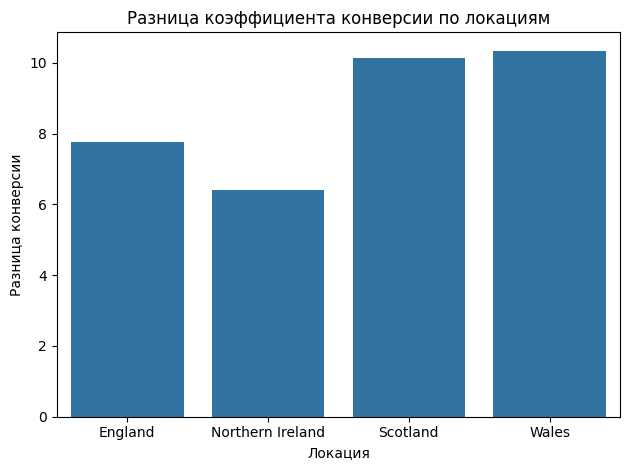

In [17]:
sns.barplot(
    x = location_uplift.index,
    y = location_uplift['B - A']
)
plt.title('Разница коэффициента конверсии по локациям')
plt.xlabel('Локация')
plt.ylabel('Разница конверсии')
plt.tight_layout()
plt.show()

Сегментный анализ по локациям показывает, что тестовая группа B превосходит контрольную группу A во всех рассмотренных географических сегментах.
Минимальное различие наблюдается в Northern Ireland, где прирост конверсии составляет около 6.4 процентов.
Наиболее выраженный эффект наблюдается в Wales и Scotland, где разница превышает 10 процентов.
Это показывает, что влияние изменения сохраняется во всех локациях, однако сила эффекта различается между сегментами.

In [18]:
device_summary = device_heatmap.copy()
device_summary['B - A'] = device_summary['B'] - device_summary['A']
device_summary

Group,A,B,B - A
Device,,,
Desktop,5.868167,13.910355,8.042188
Mobile,4.941176,14.237574,9.296397


In [20]:
location_summary = location_heatmap.copy()
location_summary['B - A'] = location_summary['B'] - location_summary['A']
location_summary

Group,A,B,B - A
Location,,,
England,6.930693,14.687500,7.756807
Northern Ireland,5.048860,11.464968,6.416108
Scotland,4.925373,15.057283,10.131910
Wales,4.769475,15.116279,10.346804


## Выводы по сегментному анализу

Сегментный анализ показал, что тестовая группа B демонстрирует более высокий коэффициент конверсии по сравнению с группой A во всех рассмотренных пользовательских сегментах.
По типу устройства наибольший прирост конверсии наблюдается в мобильном сегменте, что может указывать на более высокую чувствительность мобильных пользователей к изменениям визуального оформления интерфейса.
По географическим сегментам наиболее выраженный эффект зафиксирован в Wales и Scotland, тогда как в Northern Ireland различие между группами является менее выраженным.
Положительный эффект тестируемого изменения носит устойчивый характер и проявляется в различных пользовательских сегментах, хотя интенсивность эффекта различается.